<a href="https://colab.research.google.com/github/ctrazona1385/DS_Capstone_Group_1/blob/main/Monte_Carlo_Health_Impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import wandb

# 1. Log in to W&B (This will prompt for your API key in Colab)
wandb.login()

# 2. Initialize the W&B run
# Replace 'your-project-name' with what you want to call this project in W&B
run = wandb.init(
    entity="mmcgee18-georgia-state-university",
    project="monte-carlo-health-impact",
    name="baseline-simulation-1000",
    save_code=True, # Tells W&B to try and capture the notebook code
    config={
        "n_iterations": 1000,
        "adoption_min": 0.01,
        "adoption_mode": 0.02,
        "adoption_max": 0.03,
        "features": ['diabetes_pct', 'high_bp_pct', 'high_cholesterol_pct', 'asthma_pct', 'no_checkup_pct']
    }
)

csv_url = 'https://raw.githubusercontent.com/ctrazona1385/DS_Capstone_Group_1/main/data/v2_cleaned/all_merged.csv'
df = pd.read_csv(csv_url)

display(df.head())

,index,geoid_tract,uninsured_pct,high_bp_pct,asthma_pct,no_checkup_pct,no_dental_visit_pct,diabetes_pct,high_cholesterol_pct,geoid,...,median_household_income,hpsa_score_max,hpsa_designated,poverty_rate_pct,total_population_poverty,md_primary_care_count,do_primary_care_count,total_population,pcp_count,pcp_per_100k
0,226,1001020100,15.0,38.8,9.8,74.1,63.4,10.7,35.6,1001,...,72481.0,15.0,1.0,11.8,6988.0,24.0,1.0,59759.0,25.0,41.834703
1,2109,1001020200,19.9,43.6,10.9,76.5,55.6,13.4,32.7,1001,...,72481.0,15.0,1.0,11.8,6988.0,24.0,1.0,59759.0,25.0,41.834703
2,3955,1001020300,16.7,39.6,10.1,74.3,61.1,11.3,35.0,1001,...,72481.0,15.0,1.0,11.8,6988.0,24.0,1.0,59759.0,25.0,41.834703
3,5732,1001020400,12.5,39.2,8.8,75.5,70.3,10.2,37.7,1001,...,72481.0,15.0,1.0,11.8,6988.0,24.0,1.0,59759.0,25.0,41.834703
4,8015,1001020500,12.8,34.6,9.2,73.5,68.4,8.7,32.7,1001,...,72481.0,15.0,1.0,11.8,6988.0,24.0,1.0,59759.0,25.0,41.834703


In [5]:

# Define variables in a strict order to maintain matrix alignment
features = [
    'diabetes_pct',
    'high_bp_pct',
    'high_cholesterol_pct',
    'asthma_pct',
    'no_checkup_pct'
]

# Ensure we only process rows that have no missing values for these features and have population data
# Assuming total population is in a column like 'total_population' or similar. Using 'total_population' as placeholder.
# User needs to ensure this column exists in their DataFrame.
pop_col = 'total_population' # Adjust if the column name is different
df = df.dropna(subset=features + [pop_col] if pop_col in df.columns else features).copy()

# If pop_col is missing, we can't do absolute numbers. Let's assume it exists or use a dummy if not found for testing, but ideally it should be in the df.
if pop_col not in df.columns:
    print(f"Warning: Column '{pop_col}' not found. Using dummy population of 1000 for all tracts to demonstrate logic.")
    df[pop_col] = 1000

n_tracts = len(df)
n_iterations = 1000 # Reduced for memory management; increase if your RAM allows

# 2. Define Parameters (Means and Standard Deviations)
means = np.array([0.15, 0.12, 0.17, 0.12, 0.25])
stdevs = np.array([0.04, 0.03, 0.04, 0.03, 0.05])
adoption_params = {'min': 0.01, 'mode': 0.02, 'max': 0.03}

# 3. Build the Correlation and Covariance Matrices
# Extracted exactly from the provided image for the 5 selected features
correlation_matrix = np.array([
    # Diab  HBP   Chol  Asth  Checkup
    [1.00, 0.87, 0.52, 0.55, 0.42],  # Diabetes
    [0.87, 1.00, 0.74, 0.45, 0.64],  # High BP
    [0.52, 0.74, 1.00, -0.03, 0.49], # High Chol
    [0.55, 0.45, -0.03, 1.00, 0.24], # Asthma
    [0.42, 0.64, 0.49, 0.24, 1.00]   # No Checkup
])

# Covariance = Correlation * Outer Product of Standard Deviations
covariance_matrix = correlation_matrix * np.outer(stdevs, stdevs)

# Extract baselines into a numpy array (Shape: n_tracts x 5)
baseline_matrix = df[features].values

# Extract population (Shape: n_tracts x 1)
population_array = df[pop_col].values.reshape(-1, 1)

# Prepare a 3D array to store the results: (n_tracts, n_features, n_iterations)
simulation_results = np.zeros((n_tracts, len(features), n_iterations))

# 4. Run the Monte Carlo Simulation
print(f"Running {n_iterations} iterations for {n_tracts} census tracts...")

for i in range(n_iterations):
    # A. Draw tract-level adoption rates (Shape: n_tracts x 1)
    adoption_rates = np.random.triangular(
        adoption_params['min'],
        adoption_params['mode'],
        adoption_params['max'],
        size=(n_tracts, 1)
    )

    # B. Draw correlated tract-level reduction efficiencies (Shape: n_tracts x 5)
    # This assumes the intervention's success varies slightly per tract but remains
    # highly correlated across diseases within that specific tract.
    reductions = np.random.multivariate_normal(means, covariance_matrix, size=n_tracts)

    # Floor reductions at 0 (an intervention shouldn't increase disease prevalence)
    reductions = np.maximum(0, reductions)

    # C. Calculate Effective Improvement (Shape: n_tracts x 5)
    effective_improvement = adoption_rates * reductions

    # D. Apply to baselines to get Absolute Percentage Point Reductions (fractional form if baseline is out of 100, if percentage just treat as fraction)
    # Assuming baseline_matrix is in percentage points (e.g., 15 for 15%), we convert to fraction to multiply by population
    percentage_point_reductions = (baseline_matrix / 100.0) * effective_improvement

    # Calculate raw number of people helped (Absolute reduction in disease prevalence)
    raw_population_reduction = percentage_point_reductions * population_array

    simulation_results[:, :, i] = raw_population_reduction

# 5. Aggregate Results
results_df = df[['geoid_tract']].copy() if 'geoid_tract' in df.columns else (df[['FIPS']].copy() if 'FIPS' in df.columns else pd.DataFrame(index=df.index))

for idx, feature in enumerate(features):
    # Extract the simulated reductions for this specific feature across all iterations
    feature_sims = simulation_results[:, idx, :]

    # Calculate Mean, 5th, and 95th percentiles (absolute number of people helped)
    results_df[f'{feature}_abs_reduction_mean'] = np.mean(feature_sims, axis=1)
    results_df[f'{feature}_abs_reduction_p05'] = np.percentile(feature_sims, 5, axis=1)
    results_df[f'{feature}_abs_reduction_p95'] = np.percentile(feature_sims, 95, axis=1)

print("Simulation Complete. Sample output:")
print(results_df.head())

# Export the complete results to a CSV file
print("Exporting results to CSV...")
results_df.to_csv("monte_carlo_simulation_results.csv", index=False)

# --- ADD THIS TO THE BOTTOM OF YOUR SIMULATION CELL ---

print("Uploading results to Weights & Biases...")

# 1. Log high-level summary metrics (Average absolute reductions across all tracts)
# This will create nice line charts/bar charts in your W&B dashboard
wandb.log({
    "avg_diabetes_abs_reduction": results_df['diabetes_pct_abs_reduction_mean'].mean(),
    "avg_high_bp_abs_reduction": results_df['high_bp_pct_abs_reduction_mean'].mean(),
    "avg_high_cholesterol_abs_reduction": results_df['high_cholesterol_pct_abs_reduction_mean'].mean(),
    "avg_asthma_abs_reduction": results_df['asthma_pct_abs_reduction_mean'].mean(),
    "avg_no_checkup_abs_reduction": results_df['no_checkup_pct_abs_reduction_mean'].mean()
})

# 2. Save a sample of the results as an interactive W&B Table
# We take the first 100 rows to prevent the table from being too massive
results_table = wandb.Table(dataframe=results_df.head(100))
wandb.log({"sample_simulated_tracts": results_table})

# 3. Explicitly save the notebook file and results CSV to the W&B run files
# Make sure the string exactly matches your file name in Colab
wandb.save("Monte_Carlo_Health_Impact.ipynb")
wandb.save("monte_carlo_simulation_results.csv")

# 4. Finish the run to sync everything
wandb.finish()

print("W&B Sync Complete!")


Running 1000 iterations for 71506 census tracts...
Simulation Complete. Sample output:
   geoid_tract  diabetes_pct_abs_reduction_mean  \
0   1001020100                        19.356430   
1   1001020200                        23.638365   
2   1001020300                        20.430666   
3   1001020400                        18.333122   
4   1001020500                        15.654875   

   diabetes_pct_abs_reduction_p05  diabetes_pct_abs_reduction_p95  \
0                       10.374990                       31.472371   
1                       11.387217                       37.820690   
2                        9.452246                       32.609353   
3                        9.036267                       28.390336   
4                        7.733618                       25.031925   

   high_bp_pct_abs_reduction_mean  high_bp_pct_abs_reduction_p05  \
0                       56.214089                      29.490343   
1                       61.657257                      

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


avg_asthma_abs_reduction,▁
avg_diabetes_abs_reduction,▁
avg_high_bp_abs_reduction,▁
avg_high_cholesterol_abs_reduction,▁
avg_no_checkup_abs_reduction,▁
avg_asthma_abs_reduction,265.42989
avg_diabetes_abs_reduction,356.90542
avg_high_bp_abs_reduction,808.14816
avg_high_cholesterol_abs_reduction,1167.15521
avg_no_checkup_abs_reduction,4032.8472


W&B Sync Complete!


Aggregated into 159 counties for Georgia. Loading map data...


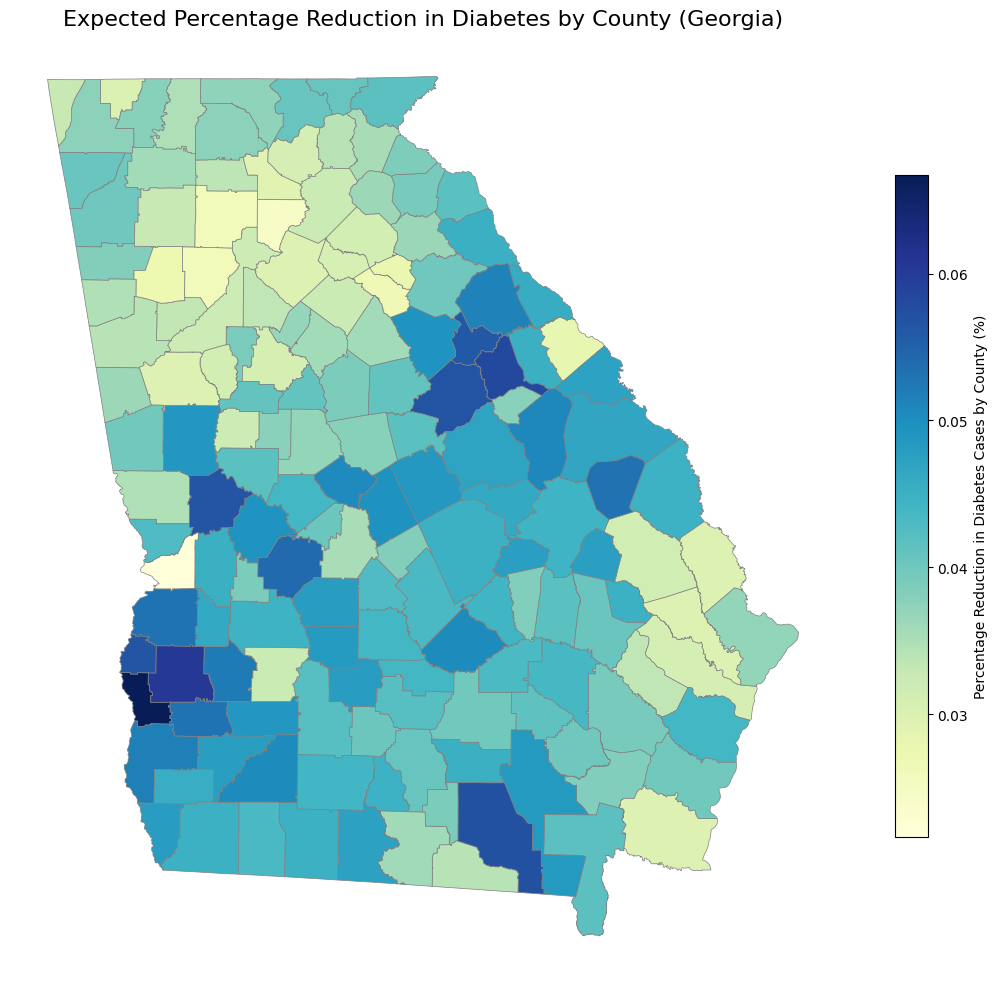

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure geoid_tract is treated as a string and padded to 11 digits
results_df['geoid_tract'] = results_df['geoid_tract'].astype(str).str.zfill(11)

# We need the population data from the original df to calculate percentages
df_pop = df[['geoid_tract', 'total_population']].copy() if 'total_population' in df.columns else df[['geoid_tract']].copy()
df_pop['geoid_tract'] = df_pop['geoid_tract'].astype(str).str.zfill(11)

# Merge population into results
merged_results = results_df.merge(df_pop, on='geoid_tract', how='left')

# Filter for Georgia (State FIPS code is '13')
ga_results = merged_results[merged_results['geoid_tract'].str.startswith('13')].copy()

# Extract 5-digit County FIPS code (first 5 digits of tract GEOID)
ga_results['county_fips'] = ga_results['geoid_tract'].str[:5]

# Aggregate by county (Summing the absolute raw reductions and population)
ga_county_results = ga_results.groupby('county_fips')[['diabetes_pct_abs_reduction_mean', 'total_population']].sum().reset_index()

# Calculate the percentage reduction
ga_county_results['diabetes_reduction_percentage'] = (ga_county_results['diabetes_pct_abs_reduction_mean'] / ga_county_results['total_population']) * 100

print(f"Aggregated into {len(ga_county_results)} counties for Georgia. Loading map data...")

# Download US Counties shapefile directly from the US Census Bureau
counties_url = "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
us_counties = gpd.read_file(counties_url)

# Filter shapefile for Georgia (STATEFP = '13')
ga_counties = us_counties[us_counties['STATEFP'] == '13']

# Merge the shapefile with our county-level simulation results
ga_map_data = ga_counties.merge(ga_county_results, left_on='GEOID', right_on='county_fips')

# Plot the choropleth map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ga_map_data.plot(
    column='diabetes_reduction_percentage',
    cmap='YlGnBu',
    linewidth=0.5,
    ax=ax,
    edgecolor='0.5',
    legend=True,
    legend_kwds={'label': "Percentage Reduction in Diabetes Cases by County (%)", 'shrink': 0.7}
)

ax.set_title("Expected Percentage Reduction in Diabetes by County (Georgia)", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()